In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [187]:
df = pd.read_csv('insurance.csv')

**EDA**

In [5]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [9]:
df.shape

(1338, 7)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [13]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before opera

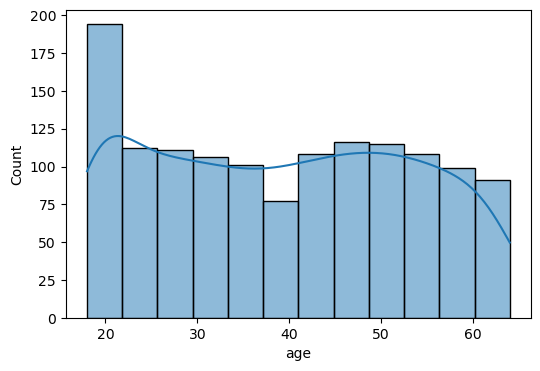

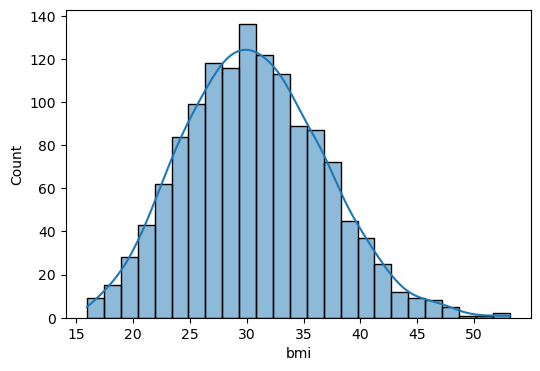

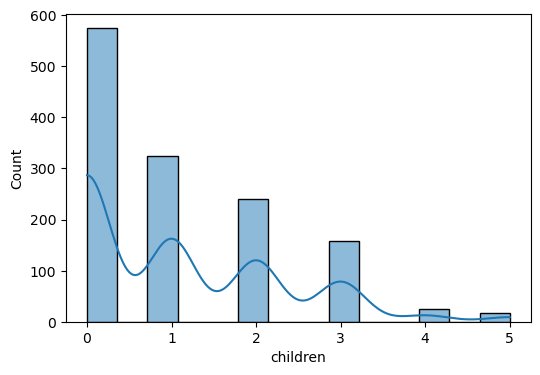

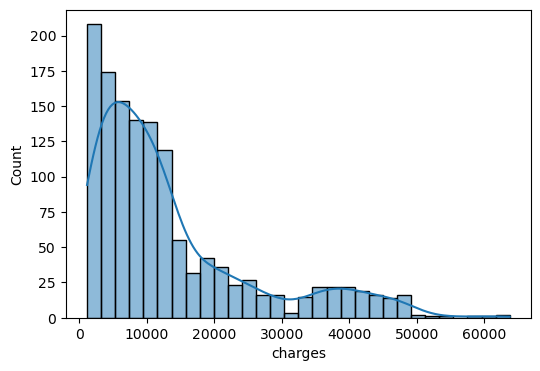

In [25]:
numeric_cols = ['age', 'bmi', 'children', 'charges']
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(data=df[col], kde=True)

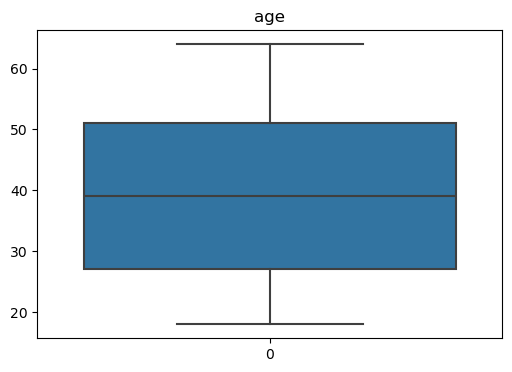

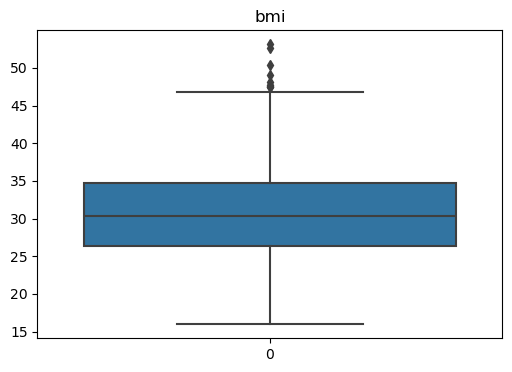

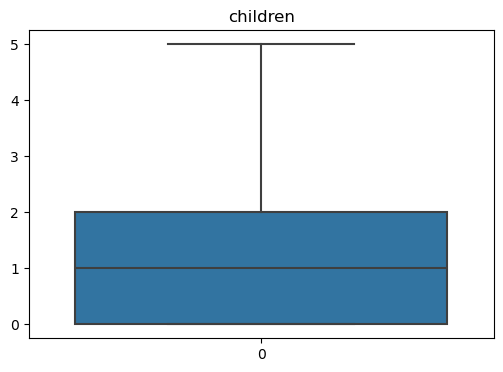

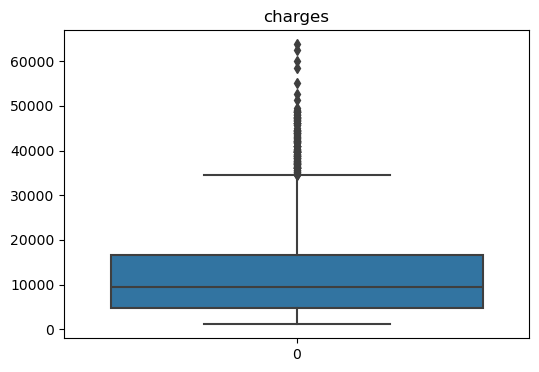

In [31]:
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    plt.title(col)
    sns.boxplot(df[col])

<Axes: >

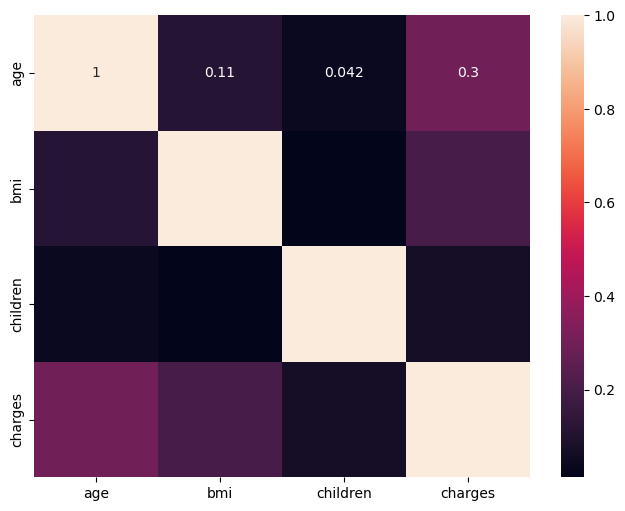

In [47]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)

In [49]:
corr_matrix = df.corr(numeric_only=True)
print(corr_matrix)

               age       bmi  children   charges
age       1.000000  0.109272  0.042469  0.299008
bmi       0.109272  1.000000  0.012759  0.198341
children  0.042469  0.012759  1.000000  0.067998
charges   0.299008  0.198341  0.067998  1.000000


In [51]:
df['sex'].value_counts()

sex
male      676
female    662
Name: count, dtype: int64

<Axes: xlabel='smoker', ylabel='charges'>

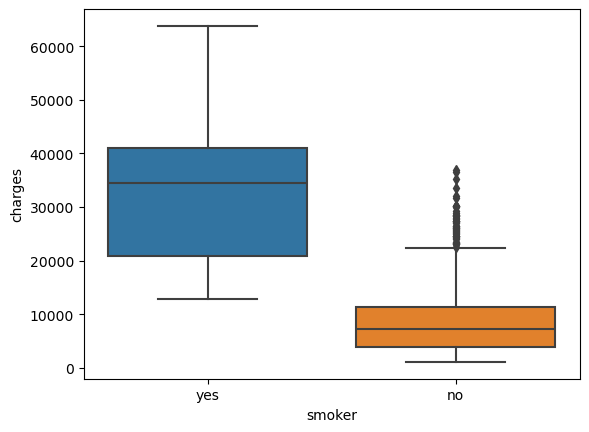

In [53]:
plt.figure()
sns.boxplot(x=df['smoker'], y=df['charges'])

**Data Cleaning and Preprocessing**

In [189]:
df_clean = df

In [191]:
df_clean

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [193]:
df_clean['sex'] = df_clean['sex'].map({'female':1, 'male':0})
df_clean['smoker'] = df_clean['smoker'].map({'yes':1, 'no':0})
df_clean

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,northwest,10600.54830
1334,18,1,31.920,0,0,northeast,2205.98080
1335,18,1,36.850,0,0,southeast,1629.83350
1336,21,1,25.800,0,0,southwest,2007.94500


In [195]:
df_clean.rename(columns=({'sex':'is_female','smoker':'is_smoker'}),inplace=True)

In [197]:
df_clean = pd.get_dummies(df_clean,columns=['region'],drop_first=True)
df_clean

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,True
1,18,0,33.770,1,0,1725.55230,False,True,False
2,28,0,33.000,3,0,4449.46200,False,True,False
3,33,0,22.705,0,0,21984.47061,True,False,False
4,32,0,28.880,0,0,3866.85520,True,False,False
...,...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,10600.54830,True,False,False
1334,18,1,31.920,0,0,2205.98080,False,False,False
1335,18,1,36.850,0,0,1629.83350,False,True,False
1336,21,1,25.800,0,0,2007.94500,False,False,True


In [199]:
df_clean[['region_northwest', 'region_southeast', 'region_southwest']] = df_clean[['region_northwest', 'region_southeast', 'region_southwest']].astype(int)

In [201]:
df_clean

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,0,0,1
1,18,0,33.770,1,0,1725.55230,0,1,0
2,28,0,33.000,3,0,4449.46200,0,1,0
3,33,0,22.705,0,0,21984.47061,1,0,0
4,32,0,28.880,0,0,3866.85520,1,0,0
...,...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,10600.54830,1,0,0
1334,18,1,31.920,0,0,2205.98080,0,0,0
1335,18,1,36.850,0,0,1629.83350,0,1,0
1336,21,1,25.800,0,0,2007.94500,0,0,1


In [203]:
df_clean['bmi_category']=pd.cut(df_clean['bmi'],bins=[0,18.5, 24.9, 29.9, float('inf')], labels=['Underweight','Normal','Overweight','Obese'])
df_clean

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category
0,19,1,27.900,0,1,16884.92400,0,0,1,Overweight
1,18,0,33.770,1,0,1725.55230,0,1,0,Obese
2,28,0,33.000,3,0,4449.46200,0,1,0,Obese
3,33,0,22.705,0,0,21984.47061,1,0,0,Normal
4,32,0,28.880,0,0,3866.85520,1,0,0,Overweight
...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,10600.54830,1,0,0,Obese
1334,18,1,31.920,0,0,2205.98080,0,0,0,Obese
1335,18,1,36.850,0,0,1629.83350,0,1,0,Obese
1336,21,1,25.800,0,0,2007.94500,0,0,1,Overweight


In [205]:
from sklearn.preprocessing import StandardScaler
cols = ['age','bmi','children']
scaler = StandardScaler()
df_clean[cols] = scaler.fit_transform(df_clean[cols])

In [207]:
df_clean

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category
0,-1.438764,1,-0.453320,-0.908614,1,16884.92400,0,0,1,Overweight
1,-1.509965,0,0.509621,-0.078767,0,1725.55230,0,1,0,Obese
2,-0.797954,0,0.383307,1.580926,0,4449.46200,0,1,0,Obese
3,-0.441948,0,-1.305531,-0.908614,0,21984.47061,1,0,0,Normal
4,-0.513149,0,-0.292556,-0.908614,0,3866.85520,1,0,0,Overweight
...,...,...,...,...,...,...,...,...,...,...
1333,0.768473,0,0.050297,1.580926,0,10600.54830,1,0,0,Obese
1334,-1.509965,1,0.206139,-0.908614,0,2205.98080,0,0,0,Obese
1335,-1.509965,1,1.014878,-0.908614,0,1629.83350,0,1,0,Obese
1336,-1.296362,1,-0.797813,-0.908614,0,2007.94500,0,0,1,Overweight


In [209]:
df_clean = pd.get_dummies(df_clean,columns=['bmi_category'],drop_first=True)
df_clean

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,-1.438764,1,-0.453320,-0.908614,1,16884.92400,0,0,1,False,True,False
1,-1.509965,0,0.509621,-0.078767,0,1725.55230,0,1,0,False,False,True
2,-0.797954,0,0.383307,1.580926,0,4449.46200,0,1,0,False,False,True
3,-0.441948,0,-1.305531,-0.908614,0,21984.47061,1,0,0,True,False,False
4,-0.513149,0,-0.292556,-0.908614,0,3866.85520,1,0,0,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,0.768473,0,0.050297,1.580926,0,10600.54830,1,0,0,False,False,True
1334,-1.509965,1,0.206139,-0.908614,0,2205.98080,0,0,0,False,False,True
1335,-1.509965,1,1.014878,-0.908614,0,1629.83350,0,1,0,False,False,True
1336,-1.296362,1,-0.797813,-0.908614,0,2007.94500,0,0,1,False,True,False


In [213]:
df_clean[['bmi_category_Normal', 'bmi_category_Overweight','bmi_category_Obese']]=df_clean[['bmi_category_Normal','bmi_category_Overweight','bmi_category_Obese']].astype(int)
df_clean

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,-1.438764,1,-0.453320,-0.908614,1,16884.92400,0,0,1,0,1,0
1,-1.509965,0,0.509621,-0.078767,0,1725.55230,0,1,0,0,0,1
2,-0.797954,0,0.383307,1.580926,0,4449.46200,0,1,0,0,0,1
3,-0.441948,0,-1.305531,-0.908614,0,21984.47061,1,0,0,1,0,0
4,-0.513149,0,-0.292556,-0.908614,0,3866.85520,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,0.768473,0,0.050297,1.580926,0,10600.54830,1,0,0,0,0,1
1334,-1.509965,1,0.206139,-0.908614,0,2205.98080,0,0,0,0,0,1
1335,-1.509965,1,1.014878,-0.908614,0,1629.83350,0,1,0,0,0,1
1336,-1.296362,1,-0.797813,-0.908614,0,2007.94500,0,0,1,0,1,0


In [215]:
from sklearn.feature_selection import mutual_info_regression

selected_features = [
    'age', 'bmi', 'children', 'is_female', 'is_smoker',
    'region_northwest', 'region_southeast', 'region_southwest',
    'bmi_category_Normal', 'bmi_category_Overweight', 'bmi_category_Obese'
]

X = df_clean[selected_features]
y = df_clean['charges']

mi_scores = mutual_info_regression(X, y, random_state=42)
mi_df = pd.Series(mi_scores, index=selected_features).sort_values(ascending=False)
mi_df

age                        1.494818
is_smoker                  0.369171
is_female                  0.176660
children                   0.162037
bmi_category_Obese         0.085800
bmi                        0.073572
region_northwest           0.057682
bmi_category_Overweight    0.040164
region_southeast           0.035070
bmi_category_Normal        0.032207
region_southwest           0.002621
dtype: float64

In [217]:
correlation_df = df_clean[selected_features].corrwith(df_clean['charges']).sort_values(ascending=False)
correlation_df

is_smoker                  0.787251
age                        0.299008
bmi                        0.198341
bmi_category_Obese         0.196857
region_southeast           0.073982
children                   0.067998
region_northwest          -0.039905
region_southwest          -0.043210
is_female                 -0.057292
bmi_category_Normal       -0.105291
bmi_category_Overweight   -0.117768
dtype: float64

In [219]:
from sklearn.feature_selection import SelectKBest, chi2

cat_features = [
    'is_female', 'is_smoker',
    'region_northwest', 'region_southeast', 'region_southwest',
    'bmi_category_Normal', 'bmi_category_Overweight', 'bmi_category_Obese'
]

X_cat = df_clean[cat_features]
y_binned = pd.qcut(df_clean['charges'], q=4, labels=False)

chi2_stats, p_values = chi2(X_cat, y_binned)
chi2_df = pd.DataFrame({'Feature': cat_features, 'chi2_stat': chi2_stats, 'p_value': p_values})
chi2_df.sort_values(by='p_value')

,Feature,chi2_stat,p_value
1,is_smoker,679.131214,7.032108e-147
3,region_southeast,11.071289,1.134657e-02
0,is_female,4.815935,1.857822e-01
4,region_southwest,4.187388,2.419276e-01
7,bmi_category_Obese,3.542255,3.153231e-01
5,bmi_category_Normal,3.451935,3.270497e-01
6,bmi_category_Overweight,3.313389,3.457835e-01
2,region_northwest,0.928289,8.185961e-01
